# 04 — XGBoost optimisé avec Optuna

## 🎯 Objectif

Entraîner un **XGBoost optimisé** et le comparer à notre baseline Random Forest.

Hypothèse de travail : XGBoost devrait surpasser RF, notamment sur les classes difficiles (Bot, Web Attack).

## 📋 Plan

1. **Setup et chargement** (mêmes splits que RF pour comparaison rigoureuse)
2. **XGBoost "vanille"** : un premier modèle sans tuning, pour avoir une référence
3. **Optuna** : recherche automatique des meilleurs hyperparamètres (30 essais)
4. **XGBoost optimisé** : entraînement final avec les meilleurs paramètres
5. **Évaluation détaillée** : métriques + matrice de confusion
6. **Comparaison RF vs XGBoost**

## ⏱️ Temps estimé

- XGBoost vanille : ~3 min sur GPU
- Optuna 30 essais : ~30-60 min sur GPU
- XGBoost final : ~3 min
- **Total : ~1h**

Le GPU sera bien sollicité pendant Optuna. Ne ferme pas le notebook.

## 1. Setup et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from time import time

import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# Affichage
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Réduit le bruit d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Chemins (mêmes que notebook 03)
DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')

# Random seed pour reproductibilité
SEED = 42
np.random.seed(SEED)

# Vérifier que XGBoost détecte le GPU
print(f'✅ XGBoost version : {xgb.__version__}')
print(f'✅ Optuna version : {optuna.__version__}')

✅ XGBoost version : 3.3.0
✅ Optuna version : 4.9.0


## 2. Chargement des données

### 📚 Reproductibilité scientifique

On utilise **exactement le même split** que pour Random Forest (même `SEED=42`, même méthode de stratification). C'est crucial : si on changeait le split, on ne pourrait pas comparer rigoureusement RF et XGBoost — la différence pourrait venir du split plutôt que du modèle.

In [2]:
# Chargement du dataset propre
t0 = time()
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')
print(f'⏱️  Chargement : {time()-t0:.1f}s — Shape : {df.shape}')

# Chargement du mapping des classes
with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]
num_classes = len(class_names)
print(f'🏷️  Classes ({num_classes}) : {class_names}')

⏱️  Chargement : 2.3s — Shape : (2517876, 79)
🏷️  Classes (7) : ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack']


In [ ]:
# X et y
y = df['Label_encoded'].values
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values

# Split identique au notebook 03
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85,
    stratify=y_trainval, random_state=SEED
)

print(f'Train : {X_train.shape[0]:>10,}')
print(f'Val   : {X_val.shape[0]:>10,}')
print(f'Test  : {X_test.shape[0]:>10,}')

Train :  1,762,512
Val   :    377,682
Test  :    377,682


In [4]:
# Calcul des sample_weights pour gérer le déséquilibre
# Équivalent du class_weight='balanced' qu'on avait utilisé pour RF
sample_weights_train = compute_sample_weight('balanced', y_train)
print(f'Sample weights calculés. Range : [{sample_weights_train.min():.4f}, {sample_weights_train.max():.4f}]')
print(f'Les classes rares (Bot, Web Attack) auront un poids beaucoup plus élevé.')

Sample weights calculés. Range : [0.1719, 184.5949]
Les classes rares (Bot, Web Attack) auront un poids beaucoup plus élevé.


## 3. XGBoost "vanille" (référence sans tuning)

### 📚 Pourquoi un baseline XGBoost AVANT le tuning ?

Pour mesurer **l'apport du tuning Optuna**. Sans cette référence, on ne peut pas dire si le gain final vient de XGBoost lui-même ou de l'optimisation.

C'est la même logique scientifique que d'avoir RF comme baseline : à chaque étape, on isole la source du gain.

In [5]:
# Hyperparamètres par défaut (raisonnables)
xgb_vanilla_params = {
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda',          # ⭐ Utilise ton GPU
    'random_state': SEED,
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
}

print('🚀 Entraînement XGBoost vanille...')
t0 = time()
xgb_vanilla = xgb.XGBClassifier(**xgb_vanilla_params)
xgb_vanilla.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
elapsed_vanilla = time() - t0
print(f'✅ Terminé en {elapsed_vanilla:.1f}s')

🚀 Entraînement XGBoost vanille...
✅ Terminé en 32.2s


In [6]:
# Évaluation rapide du vanille
y_val_pred_vanilla = xgb_vanilla.predict(X_val)
acc_vanilla = accuracy_score(y_val, y_val_pred_vanilla)
f1_macro_vanilla = f1_score(y_val, y_val_pred_vanilla, average='macro')
f1_weighted_vanilla = f1_score(y_val, y_val_pred_vanilla, average='weighted')

print(f'📊 XGBoost VANILLE — Validation')
print(f'   Accuracy     : {acc_vanilla:.4f}')
print(f'   F1 macro     : {f1_macro_vanilla:.4f}')
print(f'   F1 pondéré   : {f1_weighted_vanilla:.4f}')

c:\Users\natha\Documents\PFE\ids-xai-pfe\.venv\Lib\site-packages\xgboost\core.py:553: UserWarning: [00:31:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


📊 XGBoost VANILLE — Validation
   Accuracy     : 0.9989
   F1 macro     : 0.9683
   F1 pondéré   : 0.9990


## 4. Optimisation des hyperparamètres avec Optuna

### 📚 Ce qu'Optuna va chercher

On définit un **espace de recherche** : pour chaque hyperparamètre, on donne une plage de valeurs raisonnables. Optuna va explorer cet espace intelligemment.

Les 9 hyperparamètres clés que Optuna va tuner :

| Hyperparamètre | Rôle | Plage testée |
|----------------|------|--------------|
| `n_estimators` | Nombre d'arbres | 100 → 800 |
| `max_depth` | Profondeur max | 4 → 12 |
| `learning_rate` | Vitesse de correction | 0.01 → 0.3 |
| `subsample` | % de lignes par arbre | 0.5 → 1.0 |
| `colsample_bytree` | % de features par arbre | 0.5 → 1.0 |
| `min_child_weight` | Régularisation | 1 → 10 |
| `gamma` | Seuil min pour splitter | 0 → 1 |
| `reg_alpha` | Régularisation L1 | 0 → 1 |
| `reg_lambda` | Régularisation L2 | 0 → 1 |

### 📚 Métrique optimisée : F1 macro

On optimise le **F1 macro** (et non l'accuracy) parce qu'on veut un modèle qui marche bien **sur toutes les classes**, pas un modèle qui se contente de bien classer BENIGN.

In [7]:
def objective(trial):
    """Fonction objectif à maximiser par Optuna.
    Pour chaque essai, on entraîne un XGBoost avec des hyperparamètres tirés,
    et on renvoie le F1 macro sur validation.
    """
    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': SEED,
        'verbosity': 0,
        # Hyperparamètres à optimiser
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    return f1


# Lancement de l'optimisation
print('🔍 Lancement Optuna — 30 essais. Ça va prendre 30-60 min, sois patient.\n')

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    study_name='xgboost_ids_xai',
)

t0 = time()
study.optimize(objective, n_trials=30, show_progress_bar=True)
elapsed_optuna = time() - t0

print(f'\n✅ Optimisation terminée en {elapsed_optuna/60:.1f} min')
print(f'   Meilleur F1 macro : {study.best_value:.4f}')
print(f'\n   Meilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'     {k} = {v}')

🔍 Lancement Optuna — 30 essais. Ça va prendre 30-60 min, sois patient.



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optimisation terminée en 29.8 min
   Meilleur F1 macro : 0.9707

   Meilleurs hyperparamètres :
     n_estimators = 367
     max_depth = 11
     learning_rate = 0.08277688592913943
     subsample = 0.9438245048353373
     colsample_bytree = 0.8419513725750356
     min_child_weight = 2
     gamma = 0.10783457417904042
     reg_alpha = 0.1169252904972853
     reg_lambda = 0.7546010826027338


### 📊 Courbe de convergence d'Optuna

Cette figure montre **comment le score s'est amélioré au fil des essais**. C'est exactement la figure que tu pourras inclure dans ton rapport pour justifier le budget de 30 essais.

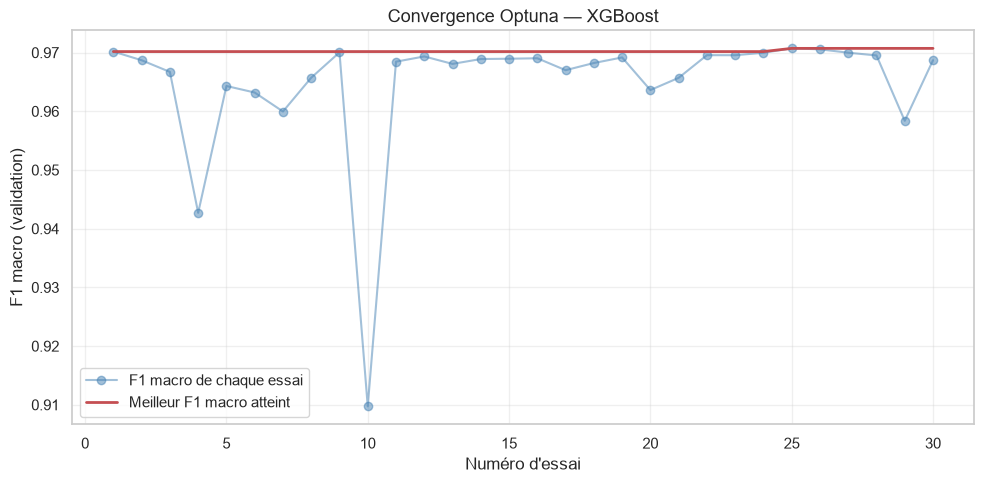

💾 Figure sauvegardée : ..\results\figures/04_optuna_convergence.png


In [8]:
# Courbe de convergence
trials = study.trials
values = [t.value for t in trials if t.value is not None]
best_so_far = np.maximum.accumulate(values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(values)+1), values, 'o-', color='steelblue', alpha=0.5, label='F1 macro de chaque essai')
ax.plot(range(1, len(values)+1), best_so_far, 'r-', linewidth=2, label='Meilleur F1 macro atteint')
ax.set_xlabel('Numéro d\'essai')
ax.set_ylabel('F1 macro (validation)')
ax.set_title('Convergence Optuna — XGBoost', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '04_optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'💾 Figure sauvegardée : {RESULTS_FIGURES}/04_optuna_convergence.png')

## 5. Entraînement final avec les meilleurs hyperparamètres

On ré-entraîne un modèle propre avec la config gagnante. C'est notre **XGBoost final** qu'on comparera à RF.

In [9]:
best_params = {
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': SEED,
    **study.best_params,
}

print('🚀 Entraînement XGBoost final avec les meilleurs hyperparamètres...')
t0 = time()
xgb_best = xgb.XGBClassifier(**best_params)
xgb_best.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
elapsed_final = time() - t0
print(f'✅ Terminé en {elapsed_final:.1f}s')

🚀 Entraînement XGBoost final avec les meilleurs hyperparamètres...
✅ Terminé en 57.4s


## 6. Évaluation détaillée

In [10]:
# Prédictions sur validation
y_val_pred_best = xgb_best.predict(X_val)

# Métriques globales
acc_best = accuracy_score(y_val, y_val_pred_best)
f1_macro_best = f1_score(y_val, y_val_pred_best, average='macro')
f1_weighted_best = f1_score(y_val, y_val_pred_best, average='weighted')

print(f'📊 XGBoost OPTIMISÉ — Validation')
print(f'   Accuracy     : {acc_best:.4f}')
print(f'   F1 macro     : {f1_macro_best:.4f}')
print(f'   F1 pondéré   : {f1_weighted_best:.4f}')

📊 XGBoost OPTIMISÉ — Validation
   Accuracy     : 0.9990
   F1 macro     : 0.9707
   F1 pondéré   : 0.9990


In [11]:
# Rapport détaillé par classe
print('📋 RAPPORT DÉTAILLÉ PAR CLASSE :\n')
report_str = classification_report(
    y_val, y_val_pred_best,
    target_names=class_names,
    digits=4
)
print(report_str)

# Sauvegarde
report_dict = classification_report(
    y_val, y_val_pred_best,
    target_names=class_names,
    output_dict=True
)
with open(RESULTS_METRICS / 'xgb_validation_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)

# Sauvegarde des meilleurs hyperparamètres
with open(RESULTS_METRICS / 'xgb_best_params.json', 'w') as f:
    json.dump({k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) 
               for k, v in study.best_params.items()}, f, indent=2)
print(f'\n💾 Rapport + best params sauvegardés dans {RESULTS_METRICS}/')

📋 RAPPORT DÉTAILLÉ PAR CLASSE :

              precision    recall  f1-score   support

      BENIGN     1.0000    0.9989    0.9994    313856
         Bot     0.6940    0.9863    0.8147       292
 Brute Force     0.9985    1.0000    0.9993      1372
        DDoS     0.9997    0.9999    0.9998     19199
         DoS     0.9977    0.9997    0.9987     29038
    PortScan     0.9886    0.9994    0.9940     13604
  Web Attack     0.9816    0.9969    0.9892       321

    accuracy                         0.9990    377682
   macro avg     0.9514    0.9973    0.9707    377682
weighted avg     0.9991    0.9990    0.9990    377682


💾 Rapport + best params sauvegardés dans ..\results\metrics/


## 7. Matrice de confusion XGBoost

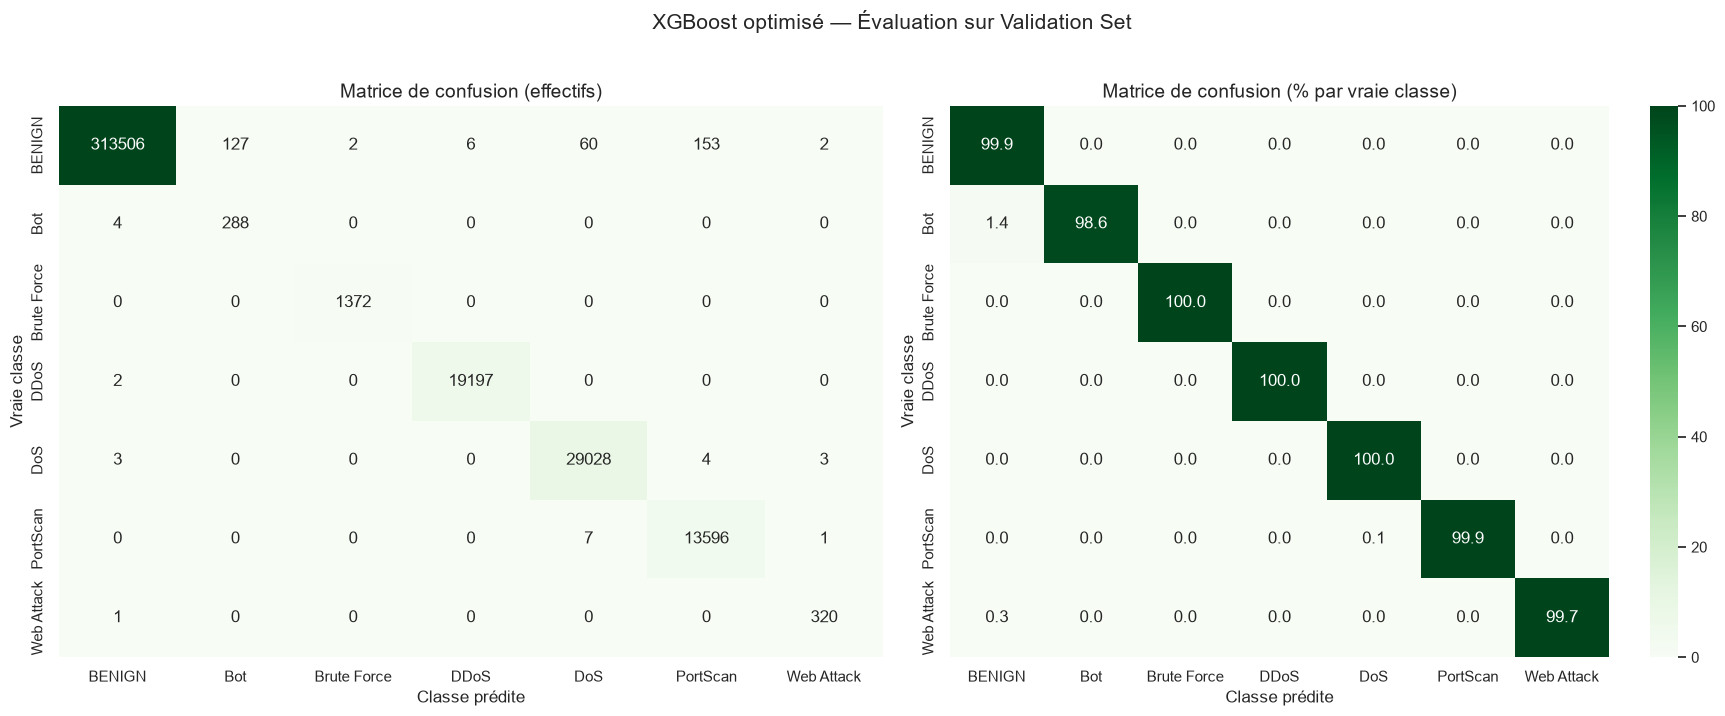

In [12]:
cm = confusion_matrix(y_val, y_val_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], cbar=False
)
axes[0].set_title('Matrice de confusion (effectifs)', fontsize=14)
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Vraie classe')

sns.heatmap(
    cm_norm, annot=True, fmt='.1f', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], cbar=True
)
axes[1].set_title('Matrice de confusion (% par vraie classe)', fontsize=14)
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Vraie classe')

plt.suptitle('XGBoost optimisé — Évaluation sur Validation Set', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '04_xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparaison Random Forest vs XGBoost

Le moment de vérité : XGBoost a-t-il battu RF ?

In [13]:
# Charger les métriques RF
with open(RESULTS_METRICS / 'rf_validation_report.json') as f:
    rf_report = json.load(f)

# Tableau comparatif
comparison = []
for cls in class_names + ['macro avg', 'weighted avg']:
    if cls in rf_report and cls in report_dict:
        comparison.append({
            'Classe': cls,
            'RF Precision': rf_report[cls]['precision'],
            'XGB Precision': report_dict[cls]['precision'],
            'Δ Precision': report_dict[cls]['precision'] - rf_report[cls]['precision'],
            'RF Recall': rf_report[cls]['recall'],
            'XGB Recall': report_dict[cls]['recall'],
            'Δ Recall': report_dict[cls]['recall'] - rf_report[cls]['recall'],
            'RF F1': rf_report[cls]['f1-score'],
            'XGB F1': report_dict[cls]['f1-score'],
            'Δ F1': report_dict[cls]['f1-score'] - rf_report[cls]['f1-score'],
        })

df_comp = pd.DataFrame(comparison)
df_comp_display = df_comp.set_index('Classe').round(4)
df_comp_display

,RF Precision,XGB Precision,Δ Precision,RF Recall,XGB Recall,Δ Recall,RF F1,XGB F1,Δ F1
Classe,,,,,,,,,
BENIGN,0.9999,1.0000,0.0000,0.9953,0.9989,0.0036,0.9976,0.9994,0.0018
Bot,0.1975,0.6940,0.4964,0.9863,0.9863,0.0000,0.3291,0.8147,0.4856
Brute Force,1.0000,0.9985,-0.0015,0.9985,1.0000,0.0015,0.9993,0.9993,0.0000
DDoS,0.9998,0.9997,-0.0002,0.9997,0.9999,0.0002,0.9998,0.9998,0.0000
DoS,0.9944,0.9977,0.0033,0.9996,0.9997,0.0001,0.9970,0.9987,0.0017
PortScan,0.9888,0.9886,-0.0002,0.9994,0.9994,0.0000,0.9941,0.9940,-0.0001
Web Attack,0.9814,0.9816,0.0002,0.9875,0.9969,0.0093,0.9845,0.9892,0.0047
macro avg,0.8803,0.9514,0.0712,0.9952,0.9973,0.0021,0.9002,0.9707,0.0705
weighted avg,0.9985,0.9991,0.0006,0.9960,0.9990,0.0030,0.9970,0.9990,0.0020


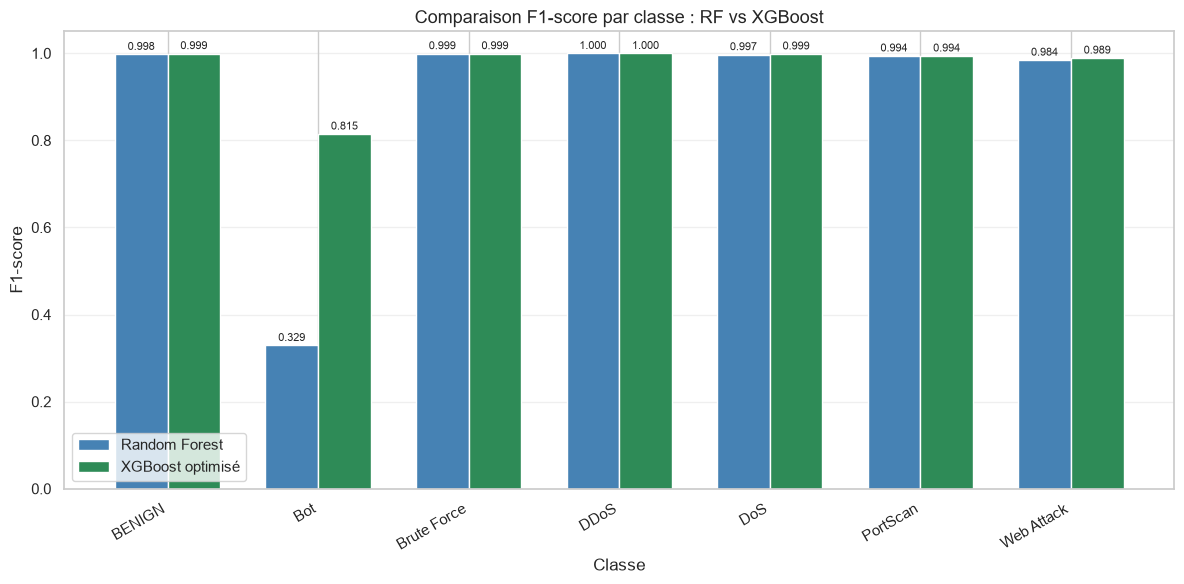

In [14]:
# Visualisation comparative : F1 par classe
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.35

rf_f1s = [rf_report[cls]['f1-score'] for cls in class_names]
xgb_f1s = [report_dict[cls]['f1-score'] for cls in class_names]

ax.bar(x - width/2, rf_f1s, width, label='Random Forest', color='steelblue')
ax.bar(x + width/2, xgb_f1s, width, label='XGBoost optimisé', color='seagreen')

ax.set_xlabel('Classe')
ax.set_ylabel('F1-score')
ax.set_title('Comparaison F1-score par classe : RF vs XGBoost', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

# Annoter les barres avec les valeurs
for i, (rf_v, xgb_v) in enumerate(zip(rf_f1s, xgb_f1s)):
    ax.text(i - width/2, rf_v + 0.01, f'{rf_v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, xgb_v + 0.01, f'{xgb_v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '04_rf_vs_xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sauvegarde du modèle

In [15]:
model_path = RESULTS_MODELS / 'xgb_optimized.joblib'
joblib.dump(xgb_best, model_path, compress=3)
size_mb = model_path.stat().st_size / 1024**2
print(f'✅ Modèle XGBoost optimisé sauvegardé : {model_path}')
print(f'   Taille : {size_mb:.1f} MB')

# Sauvegarder aussi l'étude Optuna (pour pouvoir la rejouer / continuer plus tard)
study_path = RESULTS_MODELS / 'optuna_study_xgb.pkl'
joblib.dump(study, study_path)
print(f'✅ Étude Optuna sauvegardée : {study_path}')

✅ Modèle XGBoost optimisé sauvegardé : ..\results\models\xgb_optimized.joblib
   Taille : 2.0 MB
✅ Étude Optuna sauvegardée : ..\results\models\optuna_study_xgb.pkl


## 🎉 Récapitulatif final

Tu as construit un XGBoost optimisé via 30 essais Optuna avec accélération GPU.

**Fichiers produits :**
- `results/models/xgb_optimized.joblib` : le modèle
- `results/models/optuna_study_xgb.pkl` : l'étude Optuna complète
- `results/metrics/xgb_validation_report.json` : métriques détaillées
- `results/metrics/xgb_best_params.json` : meilleurs hyperparamètres
- `results/figures/04_optuna_convergence.png` : courbe de convergence
- `results/figures/04_xgb_confusion_matrix.png` : matrice de confusion
- `results/figures/04_rf_vs_xgb_comparison.png` : comparaison RF vs XGB

### Prochaine étape (notebook 05)

**Évaluation finale sur le test set** : on évaluera RF et XGBoost sur le test (qu'on n'a jamais touché jusqu'ici). Ce sera la **conclusion officielle de la Phase B**. Ensuite, on attaquera la Phase C avec un modèle Deep Learning (DNN puis FT-Transformer).

In [1]:
from sklearn.metrics import classification_report
import pandas as pd

# y_test et y_pred de ton XGBoost sur CIC-IDS2017
# (adapte les noms de variables à ton notebook)
report = classification_report(y_test, y_pred, 
                                target_names=[CLASS_NAMES[i] for i in range(len(CLASS_NAMES))],
                                digits=4, output_dict=True)

df_report = pd.DataFrame(report).transpose()
print(df_report.to_string())

NameError: name 'y_test' is not defined